# The problem
accuracy is not always the best metric to use, proper metric depends mainly on two factors:
1. **the main goal of the project/stakeholders**
2. **is data balanced?**
# Case study: Fraud detection

## Goal?

### **First Question: Our Goal?** 

determine if this transaction is a fraud or not

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/AIML Dataset.csv


In [3]:
import pandas as pd
df = pd.read_csv('/kaggle/input/AIML Dataset.csv')

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### is it a balanced dataset?

In [5]:
print('% of each isFraud')
df['isFraud'].value_counts(normalize=True) * 100

% of each isFraud


isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [6]:
print('count for each isFraud')
df['isFraud'].value_counts()

count for each isFraud


isFraud
0    6354407
1       8213
Name: count, dtype: int64

It is not a balanced dataset, where 99.87% of the dataset is not a fraud, **USING ACCURACY: IF OUR MODEL MISCLASSIFIES THE 0.129% (WHICH IS THE TOTAL FRAUD CASES), WE WOULD STILL ACHIEVE 99.87% ACCURACY.**
## what metric to use? (confusion matrix)
|                            | **Actual Fraud (P)**               | **Actual No Fraud (N)**            
|----------------------------|----------------------------------:|----------------------------------:|
| **Predicted Fraud**    | TP (true positives)                | FP (false positives)               |                  |
| **Predicted Not Fraud** | FN (false negatives)               | TN (true negatives)                 |

so here we need to focus on:
- predicted not fraud but is actual fraud (FN)
- avoid any valid transaction as fraud(FP), so that no non-fraud account gets blocked

so we will need weighted error rate, to focus heavily on FN, **AND ONLY THE STAKEHOLDER CONTROLS THIS TRADE-OFF BASED ON THEIR PREFERENCE**

$$
\mathrm{WER}_\alpha \;=\;\alpha\,\frac{\mathrm{FN}}{P}\;+\;(1 - \alpha)\,\frac{\mathrm{FP}}{N}
$$

So alpha is chosen by the stakeholder, we will choose it by, say 0.75, which will weight FN by 0.75, and FP weight by 1 - 0.75

In [7]:
ALPHA = 0.75

## what approach to deal with this imbalanced dataset?

[There are 4 ways of addressing class imbalance problems like these:
](https://rikunert.com/SMOTE_explained)

- Synthesisis of new minority class instances
- Over-sampling of minority class
- Under-sampling of majority class
- tweak the cost function to make misclassification of minority instances more important than misclassification of majority instances

we will use the last approach.

# data cleaning/processing

In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
# check for outliers so that scaling is ok
import pandas as pd
df_iqr = df.drop(['nameOrig', 'type', 'nameDest', 'isFraud', 'isFlaggedFraud'], axis = 1)

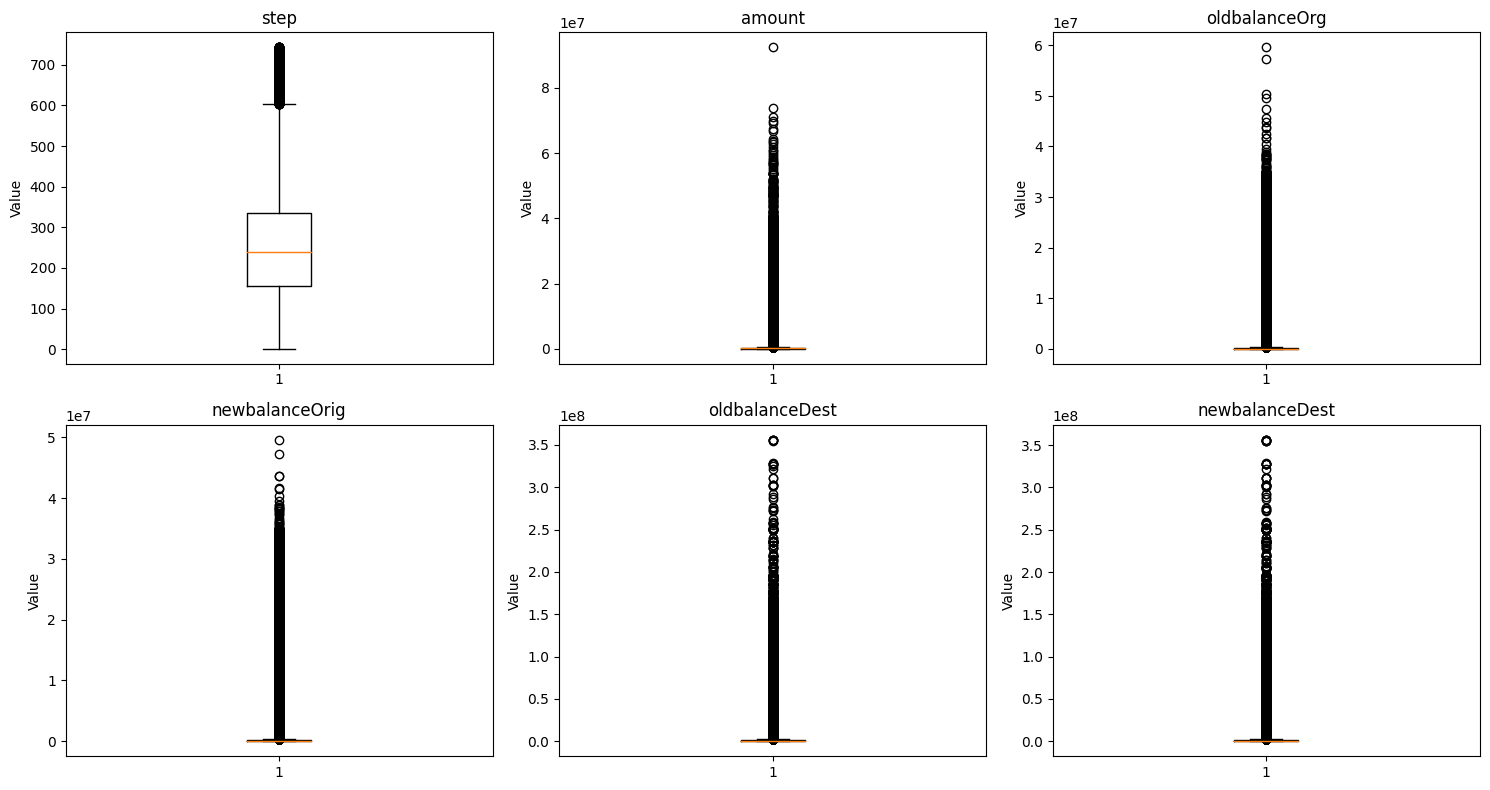

In [10]:
import math
import matplotlib.pyplot as plt

cols = df_iqr.columns
n = len(cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 4 * nrows))

axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.boxplot(df_iqr[col].dropna())
    ax.set_title(col)
    ax.set_ylabel('Value')

for ax in axes[n:]:
    ax.axis('off')

fig.tight_layout()
plt.show()


mmmmmm....

we can try log scale...

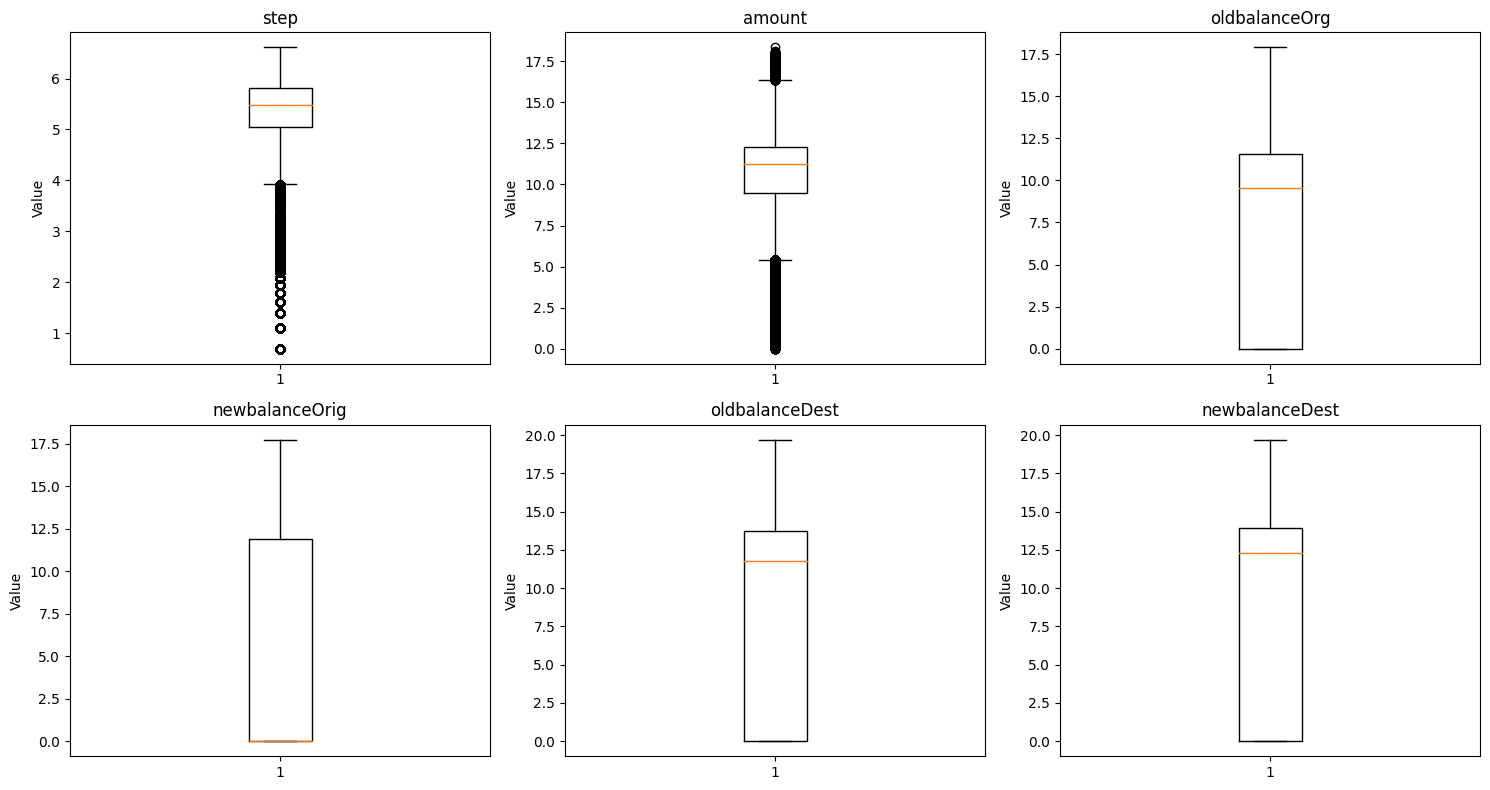

In [11]:
import numpy as np

#  log1p (log(1+x)) so zeros don’t break
df_log = df_iqr.apply(np.log1p)

cols = df_log.columns
n = len(cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 4 * nrows))

axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.boxplot(df_log[col].dropna())
    ax.set_title(col)
    ax.set_ylabel('Value')

# turn off any unused subplots
for ax in axes[n:]:
    ax.axis('off')

fig.tight_layout()
plt.show()

In [12]:
# Step denotes a portion of the time period of 5 hours, we may get more signal by extracting cyclical components
df['hours_total'] = df['step'] * 5

df['hour_sin'] = np.sin(2 * np.pi * df['hours_total'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hours_total'] / 24)

df['day_sin']  = np.sin(2 * np.pi * df['hours_total'] / (24 * 7))
df['day_cos']  = np.cos(2 * np.pi * df['hours_total'] / (24 * 7))

df['month_sin'] = np.sin(2 * np.pi * df['hours_total'] / (24 * 30))
df['month_cos'] = np.cos(2 * np.pi * df['hours_total'] / (24 * 30))
df.drop(['step', 'hours_total'], axis = 1)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,0.965926,0.258819,0.185912,0.982566,0.043619,0.999048
1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,0.965926,0.258819,0.185912,0.982566,0.043619,0.999048
2,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,0.965926,0.258819,0.185912,0.982566,0.043619,0.999048
3,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,0.965926,0.258819,0.185912,0.982566,0.043619,0.999048
4,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,0.965926,0.258819,0.185912,0.982566,0.043619,0.999048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,-0.965926,0.258819,0.652287,0.757972,0.843391,0.537300
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,-0.965926,0.258819,0.652287,0.757972,0.843391,0.537300
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,-0.965926,0.258819,0.652287,0.757972,0.843391,0.537300
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,-0.965926,0.258819,0.652287,0.757972,0.843391,0.537300


need both sine and cosine so that every point on the cycle has a unique two-dimensional embedding. If we used just one of them, different times could map to the same value and become indistinguishable to our model.

using only sin(2π·hour/24) gives

sin(0 h) = 0

sin(12 h) = 0

sin(24 h) = 0

So midnight, noon and “next midnight” all collapse to 0.

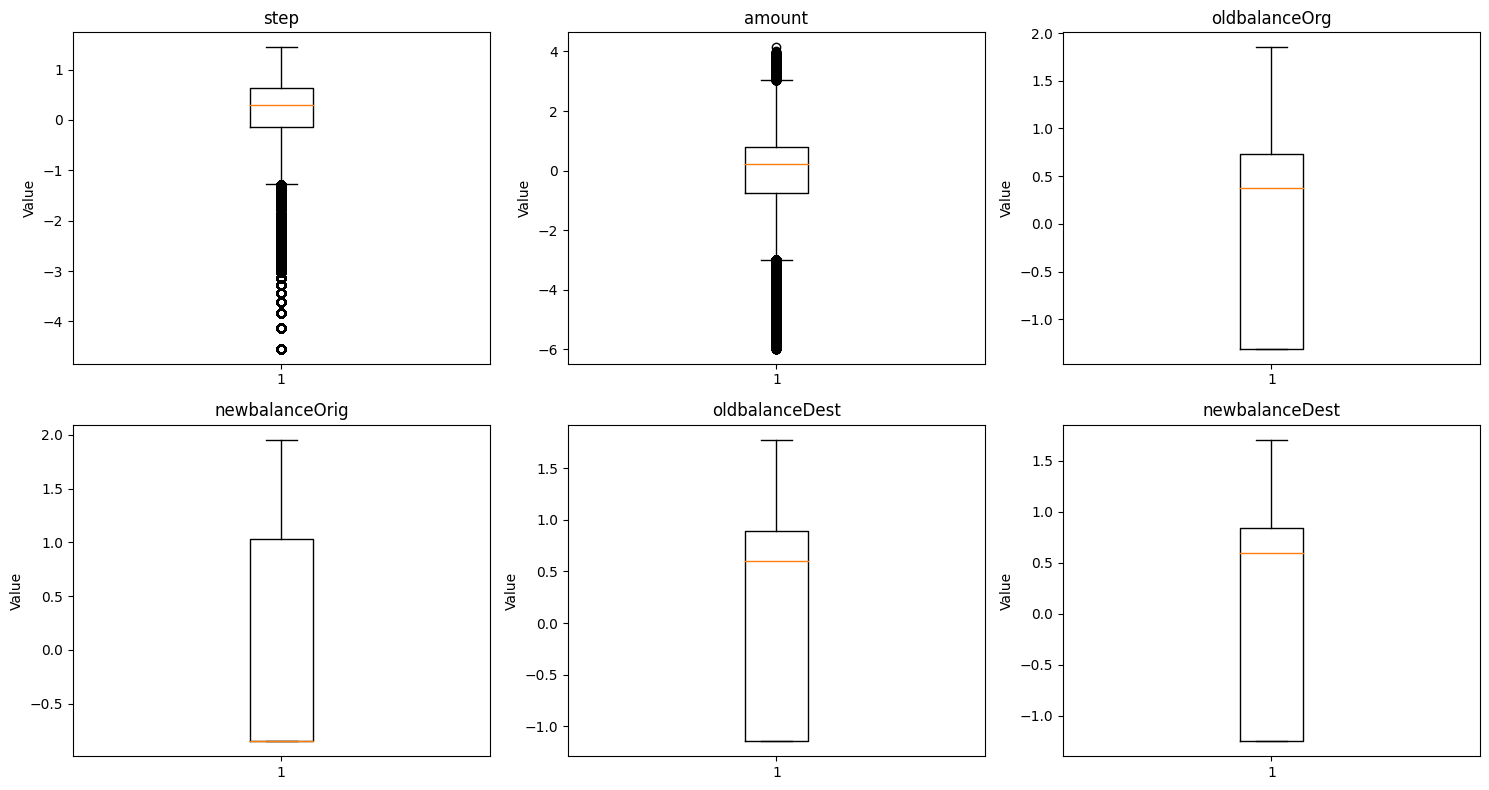

In [13]:
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
scaled_arr = ss.fit_transform(df_log)

cols   = df_log.columns
n      = len(cols)
ncols  = 3
nrows  = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(scaled_arr[:, i])
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

for ax in axes[n:]:
    ax.axis('off')

fig.tight_layout()
plt.show()

col_df = df[['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']]
scaled_arr = pd.concat([df_log, col_df], axis=1)

# Modelling
Now we need to architect our models so they’re aware of our end goal (penalizing false negatives more heavily than false positives):


In [14]:
df_cat = ['type', 'nameOrig', 'nameDest']
df_cat = df[df_cat]
X = pd.concat([scaled_arr, df_cat], axis=1)
X = X.drop(columns=['step'])
y = df['isFraud']

In [15]:
from sklearn.model_selection import train_test_split
X, X_test, y, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

In [16]:
from sklearn.metrics import confusion_matrix
def weighted_error_rate(y_true, y_pred, alpha=ALPHA):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fnr = fn / (fn+tp) if (fn + tp) > 0 else 0
    fpr = fp / (fp+tn) if (fp + tn) > 0 else 0
    return (alpha * fnr) + ((1 - alpha) * fpr)

In [17]:
cat_feats = ['type','nameOrig','nameDest']
for col in cat_feats:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [18]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cat_cols = [12, 13, 14]

def make_model():
    return LGBMClassifier(
        n_estimators=100,
        learning_rate=0.01,
        class_weight={0: 1, 1: 3}, # 1:3 is the same as 25%:75%
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
model = make_model()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_cv_pred = cross_val_predict(model, X, y, cv=skf)
total_wer_new = weighted_error_rate(y, y_cv_pred)

In [19]:
final_model = make_model()
final_model.fit(X, y, categorical_feature=cat_cols)
y_test_pred = final_model.predict(X_test)
wer_test_set = weighted_error_rate(y_test, y_test_pred)

In [20]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y, y_cv_pred).ravel()
tn_u, fp_u, fn_u, tp_u = confusion_matrix(y_test, y_test_pred).ravel()

print(f"WER CV(new model): {total_wer_new:.4f}")
print(f"WER [UNSEEN TEST SET] (new model): {wer_test_set:.4f}")
print(f"total FN from CV(new model): {fn}")
print(f"total FP from CV(new model): {fp}")
print(f"total FN from UNSEEN TEST SET(new model): {fn_u}")
print(f"total FP from UNSEEN TEST SET(new model): {fp_u}")
print(f"total FP + FN: {fp+fn+fn_u+fp_u}")

WER CV(new model): 0.2004
WER [UNSEEN TEST SET] (new model): 0.1936
total FN from CV(new model): 1865
total FP from CV(new model): 53
total FN from UNSEEN TEST SET(new model): 318
total FP from UNSEEN TEST SET(new model): 21
total FP + FN: 2257


In [21]:
P = df['isFraud'].sum()
N = len(df) - P

FN = ((df['isFraud'] == 1) & (df['isFlaggedFraud'] == 0)).sum()
FP = ((df['isFraud'] == 0) & (df['isFlaggedFraud'] == 1)).sum()

wer_existing_model = (ALPHA * (FN / P)) + ((1 - ALPHA) * (FP / N))
print(f"WER (old model) = {wer_existing_model:.4f}")
print(f'total FN (old model): {FN:.4f}')
print(f'total FP (old model): {FP:.4f}')
print(f"FP + FN: {FP+FN}")

WER (old model) = 0.7485
total FN (old model): 8197.0000
total FP (old model): 0.0000
FP + FN: 8197


# Conclusion

- Accuracy is delusional in imbalnced datasets, and confusion matrix should be used for better metrics
- Our model WER (weighted error rate) is nearly 20% (well, this is a very optimistic result, which makes me a little doubtful, i am open to your observations...)
- Old model WER is 74%
- we used a test set to ensure that the model does not overfit on the trained CV set

**Note:** trade-off between FN and FP chosen by alpha depends on the stakeholder goal

also i know that lgbm does not need scaling but will keep it for further improvement

thanks...